In [4]:
import pandas as pd
from database import connect_db

conn = connect_db()

query = "SELECT * FROM comments"

df = pd.read_sql(query, conn)

conn.close()

df.head()

C:\Users\Harnoor kaur\AppData\Local\Temp\ipykernel_4496\60870138.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,comment_id,video_id,author,comment,likes,published_at,reply_count
0,1,UgwBrUCSRnZxFoU-Ph14AaABAg,eHTXQW58WhA,@WAIT_CONTINUES,meanwhile the man in the corner the tough guy ...,0,2026-06-29 05:45:55,0
1,2,UgwZRztprNrwi0e2iRN4AaABAg,eHTXQW58WhA,@pranshukartikey8822,one of the best dancer samay,0,2026-06-29 05:44:37,0
2,3,UgxPxjA1Z3silkg582R4AaABAg,eHTXQW58WhA,@Paras-wd2ij,It has good humour but I just don't feel like ...,1,2026-06-29 05:37:29,0
3,4,UgzZoXXWcGTGNSnr9XV4AaABAg,eHTXQW58WhA,@PawanPandey-j6z8b,Nice one samay ❤,0,2026-06-29 05:32:49,0
4,5,UgzsMcEO-1fWFZnwcQB4AaABAg,eHTXQW58WhA,@whymee-3i,Crazzzzzy bhhai🎉🎉,0,2026-06-29 05:30:41,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89955 entries, 0 to 89954
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            89955 non-null  int64         
 1   comment_id    89955 non-null  object        
 2   video_id      89955 non-null  object        
 3   author        89955 non-null  object        
 4   comment       89955 non-null  object        
 5   likes         89955 non-null  int64         
 6   published_at  89955 non-null  datetime64[ns]
 7   reply_count   89955 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 5.5+ MB


In [6]:
df.shape

(89955, 8)

In [7]:
df.columns

Index(['id', 'comment_id', 'video_id', 'author', 'comment', 'likes',
       'published_at', 'reply_count'],
      dtype='object')

In [8]:
df.describe()

,id,likes,published_at,reply_count
count,89955.000000,89955.000000,89955,89955.0
mean,44987.998666,15.357234,2026-06-21 08:42:23.971574784,0.0
min,1.000000,0.000000,2026-06-20 05:34:56,0.0
25%,22499.500000,0.000000,2026-06-20 16:07:51,0.0
50%,44988.000000,0.000000,2026-06-20 19:35:07,0.0
75%,67476.500000,0.000000,2026-06-21 10:13:37,0.0
max,89965.000000,237024.000000,2026-06-29 05:59:20,0.0
std,25967.918380,993.427603,NaN,0.0


In [9]:
df.isnull().sum()

id              0
comment_id      0
video_id        0
author          0
comment         0
likes           0
published_at    0
reply_count     0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["author"].nunique()

79850

In [12]:
df["author"].value_counts().head(10)

author
@RavishankarChoudhary9    72
@SKELETON_WALLAH          28
@1404-s1n                 25
@suhailsiddiqui249        23
@KareenaSouthie           22
@TheSleeksociety          21
@jigartailor1439          21
@rezaulkarim-py2gn        20
@Ashishjha-r7r            18
@OP_AR_Rahman             18
Name: count, dtype: int64

In [13]:
df.nlargest(10, "likes")[["author", "likes", "comment"]]

,author,likes,comment
76013,@ashishsolanki_1,237024,Mai police ki taraf se hi aaya tha.
43156,@Amritsingh0077,76499,Bring That Trump In the Panel😭💀
78590,@FootnBallzz,72291,That Drunk guy lowkey gave me goosebumps when ...
44451,@smitparikh781,66585,"The people who have watched 1st season, know h..."
55066,@Vlogopinion0102,55225,First ever hit show jiska channel pe season 1 ...
81708,@seckyg171,51517,donald trump guy was fab!!!!😭😭
61261,@mehek6084,47661,For the first time bollywood celebrities were ...
53673,@svivekvardhan66,47487,doland trump first ever guy to dominate samay ...
78412,@Vicky613,35023,"Anyone read the disclaimer?\n""This video is no..."
20938,@Driftiq-n4e,32089,Trump had more confidence than the entire pane...


In [14]:
df["likes"].mean()

np.float64(15.357234172641876)

In [15]:
df["likes"].max()

np.int64(237024)

In [16]:
zero_like = (df["likes"] == 0).sum()

percentage = (zero_like / len(df)) * 100

print(f"Comments with 0 likes : {percentage:.2f}%")

Comments with 0 likes : 75.93%


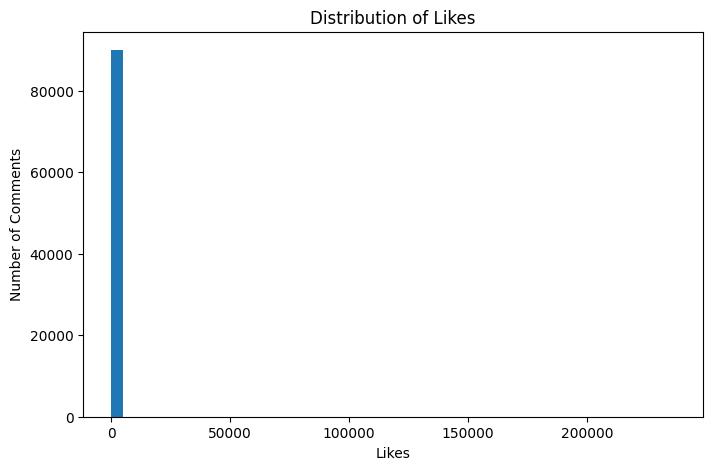

In [17]:
# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["likes"], bins=50)

plt.title("Distribution of Likes")

plt.xlabel("Likes")

plt.ylabel("Number of Comments")

plt.show()

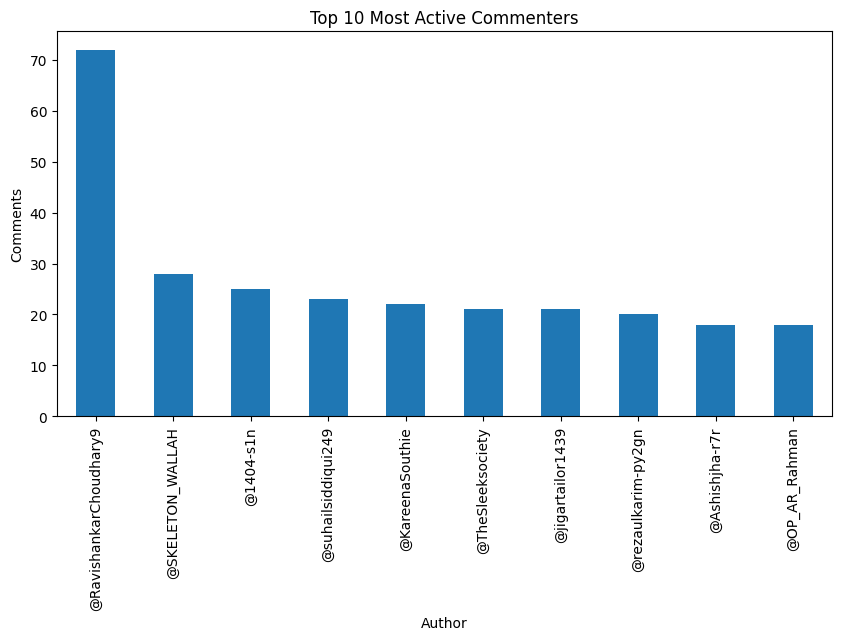

In [19]:
top_users = df["author"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_users.plot(kind="bar")

plt.title("Top 10 Most Active Commenters")

plt.xlabel("Author")

plt.ylabel("Comments")

plt.xticks(rotation=90)

plt.show()